In [ ]:
from data.loading_data import load_dataset, load_fraud_dataset, load_non_fraud_dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
dataset = load_dataset()
dataset_fraud = load_fraud_dataset()
dataset.head()

In [ ]:
x_data = dataset.drop("Class", axis=1)
y_data = dataset["Class"]
x_data_fraud = dataset_fraud.drop("Class", axis=1)
y_data_fraud = dataset_fraud["Class"]

In [ ]:
vx = 'V11'

In [ ]:
plt.scatter(x_data[vx],x_data['Amount'],  c=y_data)
plt.scatter(x_data[vx],x_data['Amount'],  c=y_data)
plt.scatter(x_data_fraud[vx],x_data_fraud['Amount'],  c='red')
plt.legend()
plt.title("Scatter, amount vs v1")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

In [ ]:
pipeline_base = make_pipeline(RobustScaler())
preprocessor = make_column_transformer((pipeline_base, ['Amount', 'Time']), remainder='passthrough')
model = make_pipeline(preprocessor, LogisticRegression(class_weight="balanced", max_iter=2900))
model.named_steps
model.fit(x_train, y_train)


In [ ]:

model.get_params()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# param_grid ={
#         'logisticregression__penalty': ['l2'],
#         'logisticregression__solver': ['lbfgs', 'sag'],
#         'logisticregression__C': [0.01, 0.1, 1, 10]
#     }
# grid = GridSearchCV(model, param_grid, cv=3, scoring='recall', n_jobs=-1)
# grid.fit(x_train, y_train)
# grid.best_params_



In [ ]:
model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', class_weight='balanced')

In [ ]:
model.fit(x_train, y_train)
model.score(x_test, y_test)


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
a = confusion_matrix(y_pred, y_test)

In [ ]:
print(f"{a[1][1] / (a[1][0] + a[1][1])*100:.2f}% des fraudes ont ete detectes")
print(f"Le score du modele est cependant impressionant avec un score de {model.score(x_test, y_test)*100:.2f}%")


In [ ]:

sns.heatmap(confusion_matrix(y_pred, y_test),
                annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["True 0", "True 1", "True 2"],
    linewidths=1,
    linecolor="black")

On va se faire un autre model qui sera plus adapte, XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
XGBClassifier()

In [ ]:
print("SIUUU")

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [ ]:
pipeline = Pipeline([
    ("model", model)
])

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

print(grid.best_params_)

In [ ]:
y_proba = grid.predict_proba(x_test)[:, 1]
y_proba

In [237]:
best_threshold = 0
best_precision = 0
min_recall = 0.8

for t in np.arange(0.1, 1.0, 0.01):
    y_pred = (y_proba > t).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_fraude = report["1"]["precision"]
    recall_fraude = report["1"]["recall"]
    
    if recall_fraude >= min_recall and precision_fraude > best_precision:
        best_precision = precision_fraude
        best_threshold = t

print(f"\nThreshold conseillé : {best_threshold:.2f}")
print(f"Precision : {best_precision:.2f}")


Threshold conseillé : 0.96
Precision : 0.73


In [238]:
y_pred = (y_proba > best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[56835    29]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.82      0.77        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [239]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# aligner lengths pour plot
thresholds_ext = np.append(thresholds, 1.0)

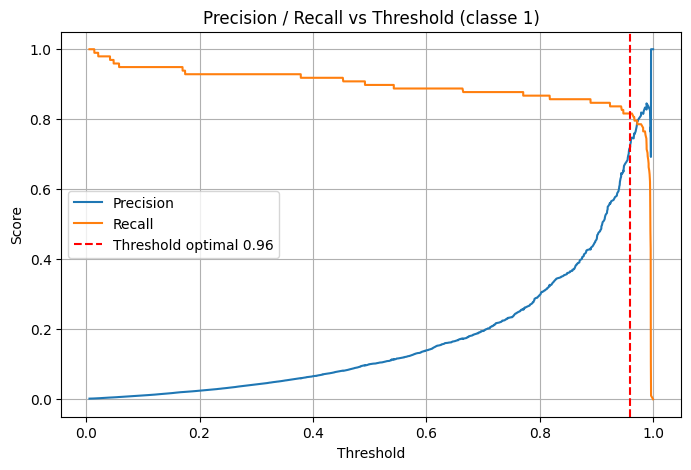

In [240]:
plt.figure(figsize=(8,5))
plt.plot(thresholds_ext, precision, label="Precision")
plt.plot(thresholds_ext, recall, label="Recall")
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Threshold optimal {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Threshold (classe 1)")
plt.legend()
plt.grid(True)
plt.show()